In [1]:
!pip install -q ipywidgets
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz shap eli5

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  libxcomposite1 libxdot4
0 upgraded, 11 newly installed, 0 to remove and 138 not upgraded.
Need to get 2,478 kB of archives.
After this operation, 7,871 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main a

In [2]:
import pydot, shap, eli5

shap.initjs()

2026-03-21 12:59:01.353199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774097941.585559      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774097941.654670      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774097942.233566      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774097942.233619      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774097942.233622      17 computation_placer.cc:177] computation placer alr

In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
os.environ["KERAS_BACKEND"] = "tensorflow"

In [5]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, PredictionErrorDisplay

## -- keras library --
import tensorflow as tf
from tensorflow.keras.utils import FeatureSpace
from tensorflow.keras.utils import plot_model

import warnings

In [6]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [7]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e3/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
    orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e3 | Customer Churn/_churn_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']]
BASE   = NUMS + CATS

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16


In [8]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
train.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0


In [10]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,594194.0,0.114102,0.317936,0.00,0.00,0.00,0.0,1.00
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80
Churn,594194.0,0.225208,0.417719,0.00,0.00,0.00,0.0,1.00


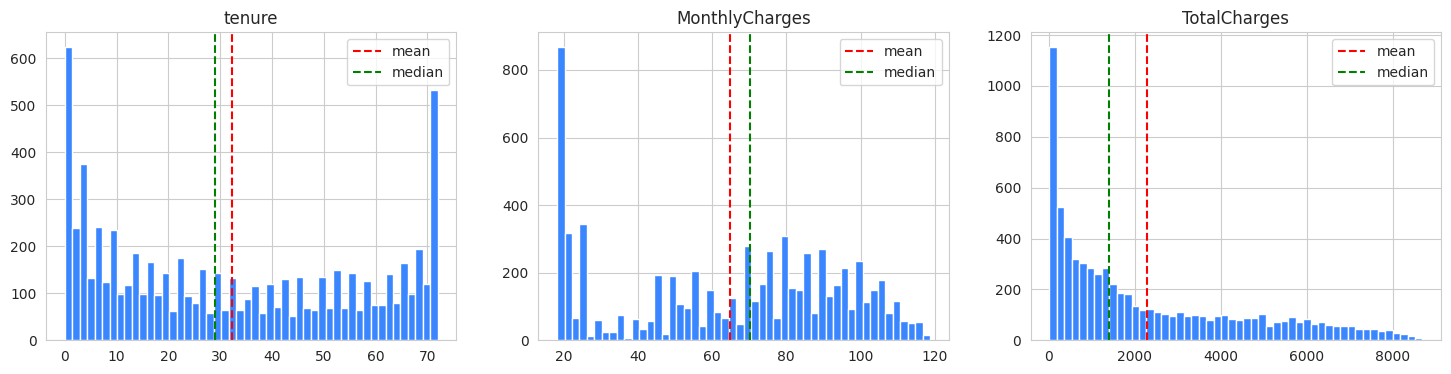

In [11]:
plt.figure(figsize=(18, 4))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'{col}')
    plt.legend()
    
plt.show()

In [12]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='bone')

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []

In [14]:
for col in ['TotalCharges']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-3, -2, -1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    # print(f"\nEXTRACTING DIGITS... ", end='')
    # for d in [-3, -2, -1, 0, 1, 2]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < 2:
    #         train = train.drop([d_n], axis=1)
    #         test  = test.drop([d_n], axis=1)
    #         orig  = orig.drop([d_n], axis=1)
    #     else:
    #         DIGITS.append(d_n)

    print(f"\nCREATING E_BINS... ", end='')
    for b in [400]: # 100, 500, 1000
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [1000]: # 100, 500, 1000
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... TotalCharges_round_-3, TotalCharges_round_-2, TotalCharges_round_-1, TotalCharges_round_0, TotalCharges_round_1, 
CREATING E_BINS... TotalCharges_bin_400, 
QUANTILE BINNING... TotalCharges_Qbin_1000, 
✅ TOTAL ROUND FEATURES: 5
✅ TOTAL DIGITS EXTRACTED: 0
✅ TOTAL EQUAL E_BINS: 1
✅ TOTAL QUANTILE E_BINS: 1


In [15]:
for col in ['MonthlyCharges']:
    print(f"\nROUNDING FEATURES... ", end='')
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    # print(f"\nEXTRACTING DIGITS... ", end='')
    # for d in [-2, -1, 0, 1, 2]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < 2:
    #         train = train.drop([d_n], axis=1)
    #         test  = test.drop([d_n], axis=1)
    #         orig  = orig.drop([d_n], axis=1)
    #     else:
    #         DIGITS.append(d_n)

    print(f"\nEQUAL BINNING... ", end='')
    for b in [100]: # 50, 100, 400
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [500]: # 50, 100, 400
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


ROUNDING FEATURES... MonthlyCharges_round_-2, MonthlyCharges_round_-1, MonthlyCharges_round_0, 
EQUAL BINNING... MonthlyCharges_bin_100, 
QUANTILE BINNING... MonthlyCharges_Qbin_500, 
✅ TOTAL DIGITS: 0
✅ TOTAL ROUNDs: 7
✅ TOTAL EQUAL BINS: 2
✅ TOTAL QUANTILE BINS: 2


In [16]:
for col in ['tenure']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    # print(f"\nEXTRACTING DIGITS... ", end='')
    # for d in [-1, 0]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < 2:
    #         train = train.drop([d_n], axis=1)
    #         test  = test.drop([d_n], axis=1)
    #         orig  = orig.drop([d_n], axis=1)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... tenure_round_-1, 
✅ TOTAL ROUND FEATURES: 8         
✅ TOTAL DIGITS FEATURES: 0         
✅ TOTAL EQUAL BINS: 2         
✅ TOTAL QUANTILE BINS: 2         


In [17]:
# train[DIGITS].nunique().sort_values()

In [18]:
ALL_ROUND_BINS = ROUNDS + E_BINS + Q_BINS

train[ALL_ROUND_BINS].nunique().sort_values()

tenure_round_-1               8
TotalCharges_round_-3        10
MonthlyCharges_round_-1      11
TotalCharges_round_-2        88
MonthlyCharges_bin_100      100
MonthlyCharges_round_0      102
TotalCharges_bin_400        396
MonthlyCharges_Qbin_500     433
TotalCharges_round_-1       846
TotalCharges_Qbin_1000      998
TotalCharges_round_1       5298
TotalCharges_round_0       5785
dtype: int64

In [19]:
CAT_50_UNIQUE  = [ c for c in ALL_ROUND_BINS if train[c].nunique() <= 50 ]
CAT_200_UNIQUE = [ c for c in ALL_ROUND_BINS if train[c].nunique() > 50 and train[c].nunique() <= 200 ]
CAT_500_UNIQUE = [ c for c in ALL_ROUND_BINS if train[c].nunique() > 200 and train[c].nunique() <= 500 ]
CAT_1K_UNIQUE  = [ c for c in ALL_ROUND_BINS if train[c].nunique() > 500 and train[c].nunique() <= 1000 ]
CAT_1KPLUS_UNIQUE  = [ c for c in ALL_ROUND_BINS if train[c].nunique() > 1000 ]

print(f"Cats ~50 unique: {len(CAT_50_UNIQUE)}")
print(f"Cats ~200 unique: {len(CAT_200_UNIQUE)}")
print(f"Cats ~500 unique: {len(CAT_500_UNIQUE)}")
print(f"Cats ~1K unique: {len(CAT_1K_UNIQUE)}")
print(f"Cats +1K unique: {len(CAT_1KPLUS_UNIQUE)}")

Cats ~50 unique: 3
Cats ~200 unique: 3
Cats ~500 unique: 2
Cats ~1K unique: 2
Cats +1K unique: 2


In [20]:
## -- Arithmetic interaction --
for df in [train, test, orig]:
    df['_MonthlyCharges_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['_TotalCharges_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
    df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_tenure'] + 1e-6)).astype('float32')
    df['_TotalCharges_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
    df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

ARITHMETIC = ['_MonthlyCharges_TotalCharges', '_TotalCharges_tenure',
              '_Monthly_to_avg_ratio', '_TotalCharges_MonthlyCharges', '_tenure_sq']

train[ARITHMETIC].head(3)

,_MonthlyCharges_TotalCharges,_TotalCharges_tenure,_Monthly_to_avg_ratio,_TotalCharges_MonthlyCharges,_tenure_sq
0,0.036339,57.029308,1.053844,27.518303,841.0
1,0.018395,65.141380,1.066910,54.362591,3364.0
2,0.017188,100.712929,0.996893,58.180775,3364.0


In [21]:
# ## -- Cyclic encoding --
# CYCLICS = []

# for col in ['MonthlyCharges', 'TotalCharges']:
#     for p in [12, 30]:
#         n_s = f'{col}_sin_{p}'
#         n_c = f'{col}_cos_{p}'
#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')

#         test[n_s] = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')

#         orig[n_s] = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')

#         CYCLICS += [n_s, n_c]

# print(f"Cylcic Features created: {len(CYCLICS)}")
# train[CYCLICS].head(3)

In [22]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)

# print()
# print(f"✅ TOTAL FREQUENCY FEATURES: {len(NUMS_FREQ)}")

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [24]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

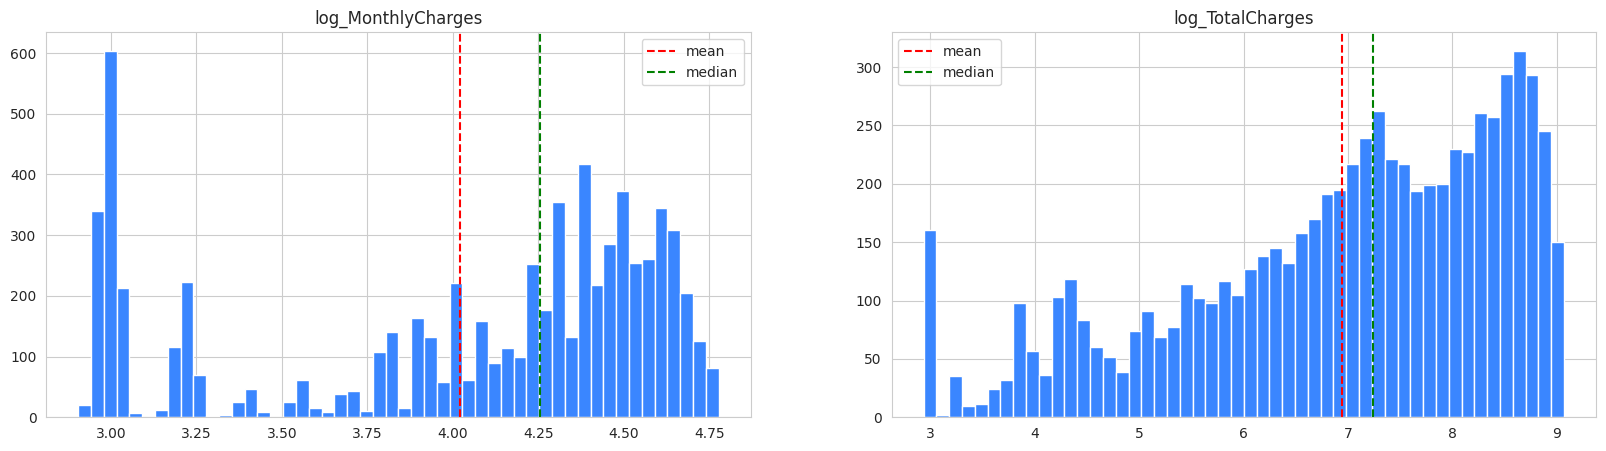

In [25]:
## -- CREATE LOG TRANSFORMED FEATURES --
for df in [train, test, orig]:
    df['log_MonthlyCharges'] = np.log(df['MonthlyCharges']) 
    df['log_TotalCharges'] = np.log(df['TotalCharges']) 

LOG_FEEATURES = ['log_MonthlyCharges', 'log_TotalCharges']

plt.figure(figsize=(20, 5))
for i, col in enumerate(LOG_FEEATURES):
    plt.subplot(1, len(LOG_FEEATURES), i+1)
    plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'{col}')
    plt.legend()

plt.show()

In [26]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE+ROUNDS, #+DIGITS, #+ROUNDS,
    target=TARGET,
    aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
    fill_nan=True,
)

TE_merging:   0%|          | 0/27 [00:00<?, ?it/s]

In [27]:
## -- DUPLICATE 'tunure' AS CATEGORICAL --
for df in [train, test, orig]:
    df['cat_tenure'] = df['tenure'].to_numpy()

print('tenure duplicated as cat_tenure')

tenure duplicated as cat_tenure


In [28]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 93


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_round_-1,_MonthlyCharges_TotalCharges,_TotalCharges_tenure,_Monthly_to_avg_ratio,_TotalCharges_MonthlyCharges,_tenure_sq,log_MonthlyCharges,log_TotalCharges,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,OTE_TotalCharges_round_-3_mean,OTE_TotalCharges_round_-3_std,OTE_TotalCharges_round_-2_mean,OTE_TotalCharges_round_-2_std,OTE_TotalCharges_round_-1_mean,OTE_TotalCharges_round_-1_std,OTE_TotalCharges_round_0_mean,OTE_TotalCharges_round_0_std,OTE_TotalCharges_round_1_mean,OTE_TotalCharges_round_1_std,OTE_MonthlyCharges_round_-1_mean,OTE_MonthlyCharges_round_-1_std,OTE_MonthlyCharges_round_0_mean,OTE_MonthlyCharges_round_0_std,OTE_tenure_round_-1_mean,OTE_tenure_round_-1_std,cat_tenure
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0,2000,1700,1650,1654,1653,75,538,60,60,41,133,30,0.036339,57.029308,1.053844,27.518303,841.0,4.096010,7.410861,0.208333,0.408966,1.000000,0.000000,0.000000,0.00000,0.261603,0.439570,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,0.228833,0.420322,0.150442,0.359097,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.154580,0.361849,0.150000,0.358870,0.214634,0.410903,29
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0,4000,3800,3780,3778,3778,173,716,70,70,50,159,60,0.018395,65.141380,1.066910,54.362591,3364.0,4.241327,8.237003,0.164179,0.373234,0.272727,0.467099,0.000000,0.00000,0.261603,0.439570,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.215315,0.411125,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.336804,0.472702,0.028319,0.165930,0.163301,0.369704,0.152431,0.359556,0.163424,0.370112,0.109091,0.314627,0.125000,0.353553,0.000000,0.000000,0.000000,0.000000,0.350195,0.477340,0.447917,0.498580,0.104326,0.305877,58
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0,6000,5800,5840,5841,5841,268,863,100,100,81,366,60,0.017188,100.712929,0.996893,58.180775,3364.0,4.609162,8.672717,0.164179,0.373234,0.000000,0.000000,0.000000,0.00000,0.261603,0.439570,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.215315,0.411125,0.391276,0.488115,0.416355,0.493025,0.300702,0.458648,0.299414,0.458085,0.427097,0.494720,0.335651,0.472274,0.452854,0.497878,0.147806,0.355318,0.133333,0.343776,0.000000,0.000000,0.000000,0.000000,0.00

# ML TRAINING

In [29]:
# def build_keras_model(
#     feature_space: tf.keras.utils.FeatureSpace=None,
#     num_layers=3,
#     dim_layers=128,
#     epochs=10,
#     learning_rate=0.01,
#     dropout_rate=0.15,
#     activation='relu',
#     l2_reg=1e-5,
#     **kwargs
# ):
#     print("⚠️ Using FeatureSpace module from TrainerCV.")

#     dict_inputs = feature_space.get_inputs()
#     encoded_features = feature_space.get_encoded_features()
#     kernel_reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0.0 else None

#     x = feature_space.get_encoded_features()
#     divisible = [1, 2, 4, 8]

#     for i, _ in enumerate(range(num_layers)):
#         v = divisible[i]
#         d = dim_layers // v
#         print(f"Layer_{i} dimension_{d} | ", end='')
#         x = tf.keras.layers.Dense(units=d, activation=activation, kernel_regularizer=kernel_reg)(x)
#         # x = tf.keras.layers.BatchNormalization()(x)
#         x = tf.keras.layers.Dropout(dropout_rate)(x)

#     outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

#     train_model = tf.keras.models.Model(inputs=encoded_features, outputs=outputs)
#     train_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss='binary_crossentropy',
#         metrics=[
#             tf.keras.metrics.AUC(name='auc'),
#             # tf.keras.metrics.BinaryAccuracy(name='accuracy')
#         ]
#     )

#     infer_model = tf.keras.models.Model(inputs=dict_inputs, outputs=outputs)

#     return train_model, infer_model

# print('⚙️ MODEL FUNCTION READY ⚙️')

In [30]:
def build_keras_model(
    feature_space: tf.keras.utils.FeatureSpace=None,
    num_layers=3,
    dim_layers=128,
    learning_rate=0.01,
    dropout_rate=0.3,
    activation='relu',
    l2_reg=0.0,
    **kwargs
    ):
    # 1. Setup Inputs
    dict_inputs = feature_space.get_inputs()

    # 2. Build the MLP using Sequential for efficiency and readability
    # We use the encoded features as the starting point
    encoded_features = feature_space.get_encoded_features()

    layers = []
    kernel_reg = tf.keras.regularizers.l2(l2_reg) if l2_reg > 0.0 else None

    for i in range(num_layers):
        # Calculate dimension d for Dense layer: halves with each layer, minimum of 32 units
        d = max(32, dim_layers // (2**i))
        layers.append(tf.keras.layers.Dense(units=d, activation=activation, kernel_regularizer=kernel_reg))
        layers.append(tf.keras.layers.BatchNormalization())
        layers.append(tf.keras.layers.Dropout(dropout_rate))
        # Increase dropout as layers get deeper/smaller -> dropout_rate+(i * 0.05)

    # Final output layer
    layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))

    # 3. Create the Sequential model for the "head"
    mlp_head = tf.keras.Sequential(layers)

    # 4. Connect everything
    outputs = mlp_head(encoded_features)
    train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)

    # 5. Compile
    train_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

    return train_model, infer_model

print('⚙️ SEQUENTIAL MODEL ⚙️')


⚙️ SEQUENTIAL MODEL ⚙️


In [31]:
## -- DEFINE TRAINER --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function(input_shape, batch_size, epochs, learning_rate, **kwargs) -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kf,            # e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        batch_size: int=32,
        epochs: int=10,
        patience: int=3,
        num_layers: int=4,
        dim_layers: int=128, # New parameter for Dense layer units
        learning_rate: float=5e-3,
        eval_metric: str='auc',  # 'auc' or 'rmse' (if you want a RMSE-like metric)
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kf = kf
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.num_layers = num_layers
        self.dim_layers = dim_layers
        self.learning_rate = learning_rate
        self.eval_metric = eval_metric

        self.result = None

        # Storage
        self.oof_preds   = np.zeros(len(train_df))
        self.test_preds  = np.zeros(len(test_df))
        self.fold_scores = []

    def _prepare_fold_data(self, X, y, X_val=None, y_val=None):
        # This helper can be extended if you want to apply masks or augmentation.
        return X, y

    def _feature_space_transform(self, train_data: pd.DataFrame, batch_input):
        feature_specs = {}

        for col in ['tenure']:
            # feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)
            # feature_specs[col] = FeatureSpace.float_discretized(num_bins=12)
            feature_specs[col] = FeatureSpace.float_normalized()

        for col in ['cat_tenure']: # +DIGITS
            feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)

        ## -- Handle floats
        for col in ['MonthlyCharges', 'TotalCharges']:
            # feature_specs[col] = FeatureSpace.float_normalized()
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=32)
            # feature_specs[col] = FeatureSpace.float_rescaled(
            #     scale=1.0 / (train_data[col].max() - train_data[col].min()),
            #     offset=-train_data[col].min() / (train_data[col].max() - train_data[col].min())
            #     )

        ## -- Categorical integers
        for col in ['SeniorCitizen']:
            feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=0)

        ## -- Handle strings
        for col in [c for c in CATS if train_data[c].dtype == 'object']:
            feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=0)

        ## -- Handle regular floats
        for col in ORIG_COLS+LOG_FEEATURES: # 
            feature_specs[col] = FeatureSpace.float()

        ## -- Handle floats
        for col in ARITHMETIC:
            feature_specs[col] = FeatureSpace.float_normalized()

        # ## -- Handle floats
        # for col in CYCLICS:
        #     feature_specs[col] = FeatureSpace.float_normalized()

        ## -- Handle floats
        for col in CAT_50_UNIQUE:
            feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)

        ## -- Handle floats
        for col in CAT_200_UNIQUE:
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=10)

        ## -- Handle floats
        for col in CAT_500_UNIQUE:
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=20)

        ## -- Handle floats
        for col in CAT_1K_UNIQUE:
            feature_specs[col] = FeatureSpace.float_discretized(num_bins=32)

        ## -- Handle floats
        for col in CAT_1KPLUS_UNIQUE:
            feature_specs[col] = FeatureSpace.float_normalized()

        TOP_CATS = [
            'Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
        ] # + DIGITS

        feature_crosses = []
        for c1, c2 in itertools.combinations(TOP_CATS, 2):
            feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=8))

        _fs = FeatureSpace(
            features=feature_specs,
            crosses=feature_crosses,
            output_mode='concat',
            name='feature_processed',
        )

        print(f'⚙️ Adapting FeatureSpace.adapt() to features... ', end='')

        ds = tf.data.Dataset.from_tensor_slices(
            (dict(train_data[self.features]), train_data[self.target])
        ).batch(batch_input)

        no_labels = ds.map(lambda x, _: x)
        _fs.adapt(no_labels)

        print(f"☑️ Complete!\n")
        return _fs

    # def _convert_infer_dict(self, X):
    #     if type(X) != 'dict':
    #         X = {name: tf.convert_to_tensor([value]) for name, value in dict(X).items()}

    #     return X

    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n==================== Starting Cross-Validation for {self.model_name} ====================")
        start = time()

        self.oof_preds  = np.zeros(len(train_df))
        self.test_preds = np.zeros(len(test_df))
        self.oof_scores = []
        self.fold_histories = []

        X = train_df[features]
        y = train_df[target]

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        feature_space_module = self._feature_space_transform(self.train_df, GLOBAL_BATCH_SIZE)

        for idx, (train_idx, val_idx) in enumerate(self.kf.split(X, y)):
            print(f"\n===== Fold {idx+1}/{self.kf.n_splits}")
            print('-'*50)

            ## -- Split data for the current fold into DataFrames --
            X_train = train_df.loc[train_idx, features]
            y_train = train_df.loc[train_idx, target]
            X_val   = train_df.loc[val_idx, features]
            y_val   = train_df.loc[val_idx, target]

            X_test  = test_df[features].copy()

            # ## -- TE Opt1. -> Using CUSTOM --
            # TE = TargetEncoder(ALL_ROUND_BINS, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            # X_train = TE.fit_transform(X_train, pd.Series(y_train))
            # X_val   = TE.transform(X_val)
            # X_test  = TE.transform(X_test)

            ## -- Create tf.data.Datasets for training and validation --
            X_train_tf = tf.data.Dataset.from_tensor_slices(
                (dict(X_train), y_train)).batch(GLOBAL_BATCH_SIZE)

            preprocessed_train_tf = X_train_tf.map(
                lambda x, y: (feature_space_module(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)

            preprocessed_train_tf = preprocessed_train_tf.prefetch(tf.data.AUTOTUNE)

            X_val_tf = tf.data.Dataset.from_tensor_slices((dict(X_val), y_val)).batch(GLOBAL_BATCH_SIZE)
            preprocessed_val_tf = X_val_tf.map(
                lambda x, y: (feature_space_module(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)

            preprocessed_val_tf = preprocessed_val_tf.prefetch(tf.data.AUTOTUNE)

            #.cache().prefetch(tf.data.AUTOTUNE)

            # X_train_dist = strategy.experimental_distribute_dataset(X_train_tf)
            # X_val_dist = strategy.experimental_distribute_dataset(X_val_tf)

            ## -- Build model --
            train_model, infer_model = self.model_builder(
                feature_space= feature_space_module,
                num_layers= self.num_layers,
                dim_layers=self.dim_layers,
                epochs= self.epochs,
                learning_rate= self.learning_rate,
                **{}  # pass additional hyperparams if needed --
            )

            ## -- Define callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss', #'val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                # tf.keras.callbacks.ReduceLROnPlateau(
                #     monitor='val_loss', #'val_auc' if self.eval_metric == 'auc' else 'val_loss',
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor='val_loss', #'val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    save_best_only=True,
                    # verbose=1
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor='val_loss', #'val_auc' if self.eval_metric == 'auc' else 'val_loss',
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- TRAIN: Collect per-fold history
            history = train_model.fit(
                preprocessed_train_tf,
                validation_data=preprocessed_val_tf,
                epochs=self.epochs,
                callbacks=callbacks,
                verbose=2,
            )
            self.fold_histories.append(history.history)

            ## -- PREDICT WITH INFERENCE MODEL --
            # Use dict(DataFrame) for prediction to match the model's dictionary input expectation
            X_val_dict = tf.data.Dataset.from_tensor_slices(dict(X_val)).batch(GLOBAL_BATCH_SIZE)
            self.oof_preds[val_idx] = infer_model.predict(X_val_dict).ravel()

            fold_auc = roc_auc_score(y_val.to_numpy(), self.oof_preds[val_idx])
            self.oof_scores.append(fold_auc)
            print(f"===== Fold {idx + 1}/{self.kf.n_splits} AUC: {fold_auc:.5f}")

            X_test_dict = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
            # X_test_dict = {name: tf.convert_to_tensor([value.ravel()]) for name, value in dict(X_test).items()}
            self.test_preds += infer_model.predict(X_test_dict).ravel()

            ## -- Save per-fold inference model --
            infer_model.save(f"{CHECKPOINT}infer_model_{idx+1}.keras")

        self.test_preds /= self.kf.n_splits

        ## -- Print final cross-validation results --
        print("\n==================================================")
        print(f"Cross-Validation Results for {self.model_name}")
        print("==================================================")
        for i, score in enumerate(self.oof_scores):
            print(f" • FOLD {i+1} AUC: {score:.5f}")

        overall_AUC  = np.round(roc_auc_score(y.to_numpy(), self.oof_preds), 5)
        avg_fold_AUC = np.round(np.mean(self.oof_scores), 5)
        std_fold_AUC = np.round(np.std(self.oof_scores), 5)

        print("-------------------------------------------------|")
        print(f"OVERALL SCORE: {overall_AUC}")
        print(f"AVERAGE SCORE: {avg_fold_AUC} \u00b1 {std_fold_AUC}")
        print("-------------------------------------------------|")
        print(f'{((time() - start) / 60):.2f} mins\n')

        print()
        display(train_model.summary())

        return {
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'fold_score': self.oof_scores,
            'avg_score': avg_fold_AUC,
            'final_score': overall_AUC,
            'infer_data': [X_val_dict, y_val],
            'history': self.fold_histories,
        }

print('⚙️ MODEL TRAINER READY ⚙️')


⚙️ MODEL TRAINER READY ⚙️


In [32]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_round_-1,_MonthlyCharges_TotalCharges,_TotalCharges_tenure,_Monthly_to_avg_ratio,_TotalCharges_MonthlyCharges,_tenure_sq,log_MonthlyCharges,log_TotalCharges,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,OTE_TotalCharges_round_-3_mean,OTE_TotalCharges_round_-3_std,OTE_TotalCharges_round_-2_mean,OTE_TotalCharges_round_-2_std,OTE_TotalCharges_round_-1_mean,OTE_TotalCharges_round_-1_std,OTE_TotalCharges_round_0_mean,OTE_TotalCharges_round_0_std,OTE_TotalCharges_round_1_mean,OTE_TotalCharges_round_1_std,OTE_MonthlyCharges_round_-1_mean,OTE_MonthlyCharges_round_-1_std,OTE_MonthlyCharges_round_0_mean,OTE_MonthlyCharges_round_0_std,OTE_tenure_round_-1_mean,OTE_tenure_round_-1_std,cat_tenure
258396,Male,0,Yes,Yes,40,No,No phone service,DSL,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,48.95,2066.00,1,2000,2100,2070,2066,2066,94,591,50,49,30,88,40,0.023693,51.649998,0.947725,42.206333,1600.0,3.890799,7.633370,0.203125,0.405505,0.400000,0.547723,0.0,0.0,0.261603,0.439570,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.249267,0.432906,0.249267,0.432906,0.189591,0.392058,0.417667,0.493245,0.399288,0.489831,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.299414,0.458085,0.427097,0.49472,0.335651,0.472274,0.452854,0.497878,0.228833,0.420322,0.278689,0.452075,0.222222,0.440959,0.0,0.00000,0.0,0.000000,0.283051,0.450863,0.328947,0.472953,0.194524,0.396120,40
227119,Female,0,Yes,No,15,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.70,324.15,0,0,300,320,324,324,14,146,20,20,1,12,20,0.060774,21.609999,0.911615,16.454313,225.0,2.980619,5.781206,0.373737,0.486257,0.046512,0.213083,0.0,0.0,0.269209,0.443612,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.250442,0.433332,0.074050,0.261938,0.074050,0.261938,0.074050,0.261938,0.074050,0.261938,0.074050,0.261938,0.074050,0.261938,0.074050,0.261938,0.427097,0.49472,0.163301,0.369704,0.191067,0.393264,0.414500,0.492759,0.349153,0.477512,0.393939,0.496198,0.5,0.57735,0.5,0.547723,0.090327,0.286752,0.087117,0.282179,0.277778,0.448147,15
341396,Female,1,No,No,49,Yes,No,DSL,No,Yes,Yes,Yes,Yes,No,Month-to-month,Yes,Mailed check,71.10,2570.20,0,3000,2600,2570,2570,2570,117,635,70,71,52,180,50,0.027663,52.453060,1.355498,36.149086,2401.0,4.264087,7.851739,0.227273,0.422282,0.142857,0.377964,0.0,0.0,0.269209,0.443612,0.416813,0.493247,0.329580,0.470125,0.312791,0.463677,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.417667,0.493245,0.215315,0.411125,0.225021,0.417682,0.151663,0.358782,0.300702,0.458648,0.336804,0.472702,0.427097,0.49472,0.335651,0.472274,0.191067,0.393264,0.248722,0.432641,0.2878

In [33]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [34]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [35]:
%%time

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

## -- Start training --
version_name  = 'kerasV0_768_'
FOLDS         = 10
LR            = 0.001
EPOCHS        = 50
PATIENCE      = 5
BATCH_SIZE    = 64
HIDDEN_LAYERS = 3
LAYER_SIZE    = 512 + 256

trainer = TrainerCV(
    model_builder=build_keras_model,
    model_name=version_name,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED),
    batch_size=BATCH_SIZE,
    num_layers=HIDDEN_LAYERS,
    dim_layers=LAYER_SIZE,
    epochs=EPOCHS,
    patience=PATIENCE,
    learning_rate=LR,
    eval_metric='auc',
)

result = trainer.fit()


==================== Starting Cross-Validation for kerasV0_768_ ====================
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
⚙️ Number of devices: 1
⚙️ Adapting FeatureSpace.adapt() to features... 

2026-03-21 13:00:04.074019: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


☑️ Complete!


===== Fold 1/10
--------------------------------------------------
Epoch 1/50
8356/8356 - 118s - 14ms/step - auc: 0.9052 - loss: 0.3171 - val_auc: 0.9131 - val_loss: 0.3043
Epoch 2/50
8356/8356 - 113s - 14ms/step - auc: 0.9107 - loss: 0.3072 - val_auc: 0.9142 - val_loss: 0.3017
Epoch 3/50
8356/8356 - 113s - 14ms/step - auc: 0.9119 - loss: 0.3053 - val_auc: 0.9143 - val_loss: 0.3014
Epoch 4/50
8356/8356 - 112s - 13ms/step - auc: 0.9126 - loss: 0.3041 - val_auc: 0.9144 - val_loss: 0.3011
Epoch 5/50
8356/8356 - 111s - 13ms/step - auc: 0.9133 - loss: 0.3031 - val_auc: 0.9147 - val_loss: 0.3007
Epoch 6/50
8356/8356 - 110s - 13ms/step - auc: 0.9136 - loss: 0.3024 - val_auc: 0.9149 - val_loss: 0.3002
Epoch 7/50
8356/8356 - 113s - 14ms/step - auc: 0.9140 - loss: 0.3018 - val_auc: 0.9149 - val_loss: 0.3001
Epoch 8/50
8356/8356 - 113s - 14ms/step - auc: 0.9143 - loss: 0.3012 - val_auc: 0.9148 - val_loss: 0.3005
Epoch 9/50
8356/8356 - 112s - 13ms/step - auc: 0.9146 - loss: 0.3008 -

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_152CLONE           │ (None, 530)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 1)              │       782,593 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,342,405 (8.94 MB)

 Trainable params: 779,905 (2.98 MB)

 Non-trainable params: 2,688 (10.50 KB)

 Optimizer params: 1,559,812 (5.95 MB)

None

CPU times: user 12h 52min 27s, sys: 49min 41s, total: 13h 42min 8s
Wall time: 4h 46min 28s


In [36]:
# ==================================================
# Cross-Validation Results for kerasV1_
# ==================================================
#  • FOLD 1 AUC: 0.91411
#  • FOLD 2 AUC: 0.91200
#  • FOLD 3 AUC: 0.91467
#  • FOLD 4 AUC: 0.91343
#  • FOLD 5 AUC: 0.91527
# -------------------------------------------------|
# OVERALL SCORE: 0.91379
# AVERAGE SCORE: 0.9139 ± 0.00113
# -------------------------------------------------|
# 20.43 mins

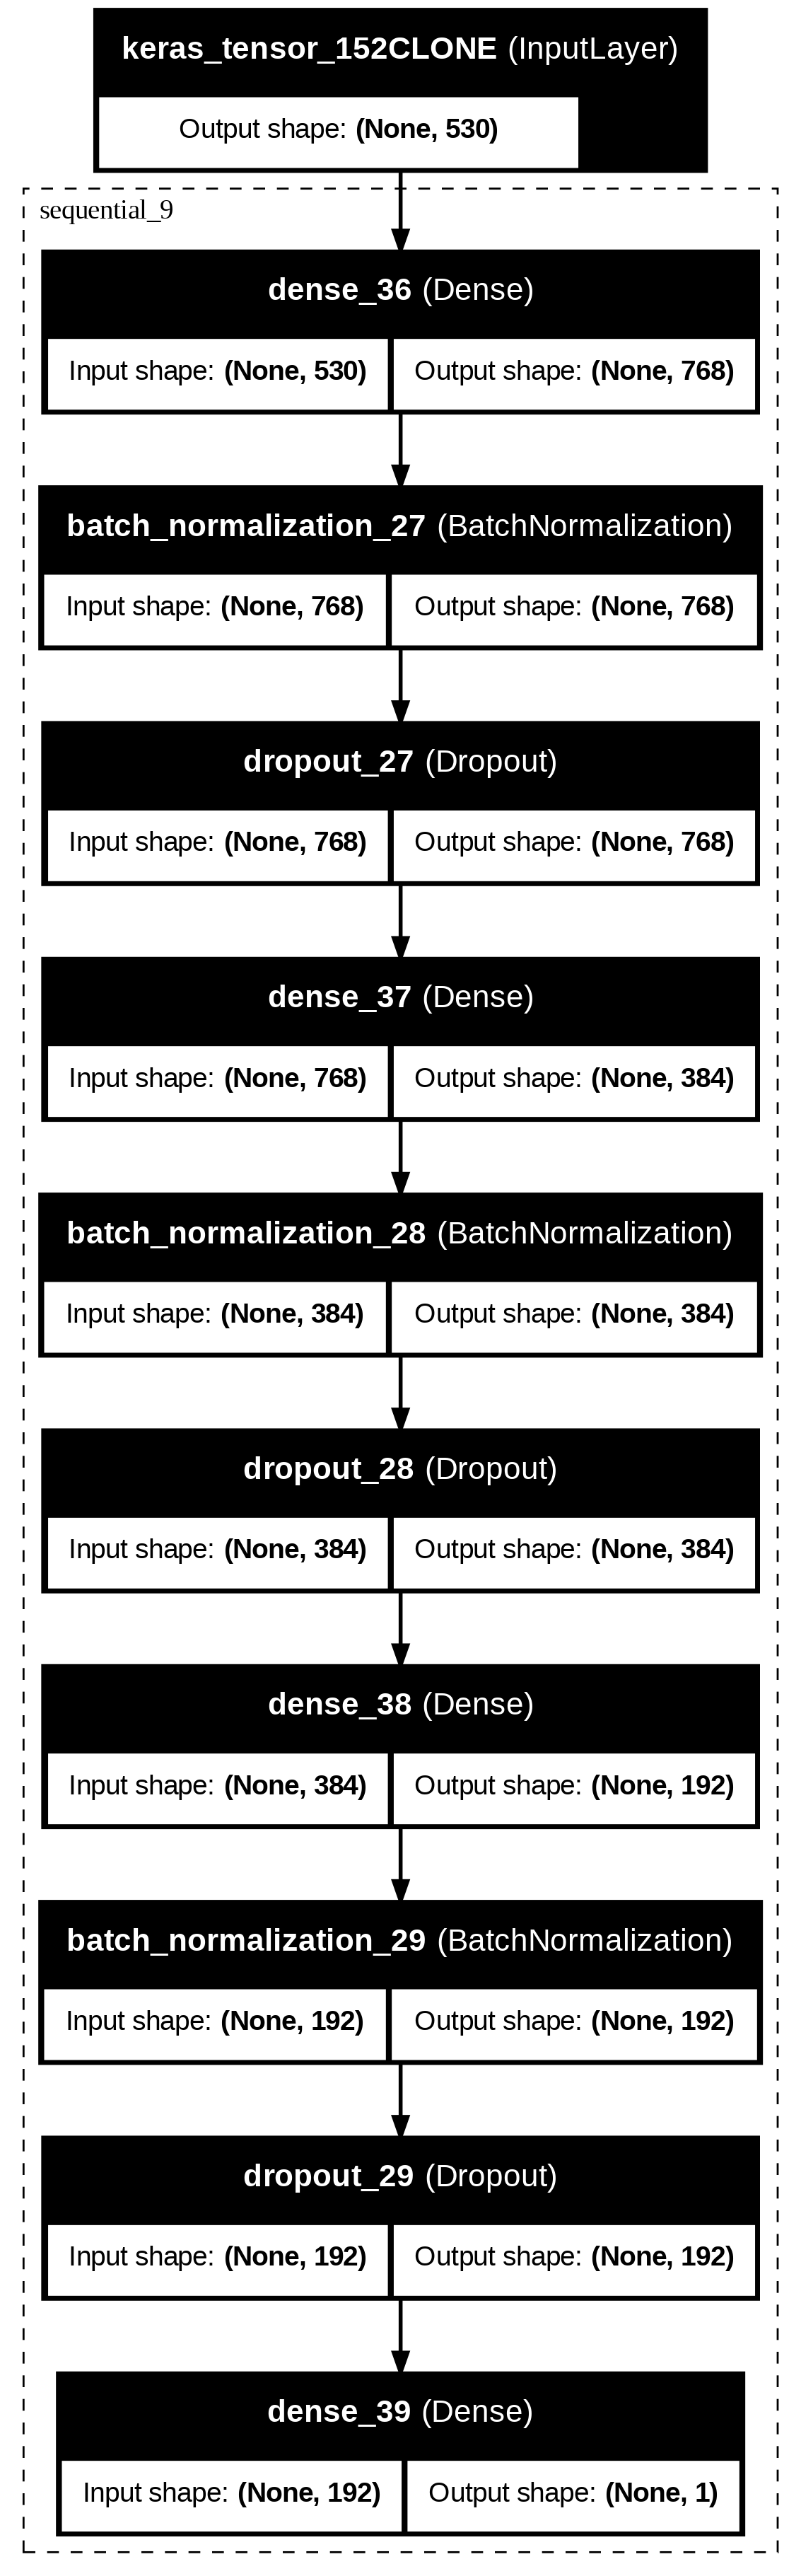

In [37]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")

plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

In [38]:
# ## -- MODEL EVALUATION FROM LAST TRAINER --
# print('========= EVALUATE BEST MODEL')
# inference_model_to_eval = tf.keras.models.load_model(f"{CHECKPOINT}infer_model_1.keras")

# # Re-compile the loaded model to enable evaluation
# inference_model_to_eval.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
#     loss='binary_crossentropy',
#     metrics=[
#         tf.keras.metrics.AUC(name='auc')
#     ]
# )

# inference_model_to_eval.evaluate(result['infer_data'][0])

  0%|          | 0/10 [00:00<?, ?it/s]

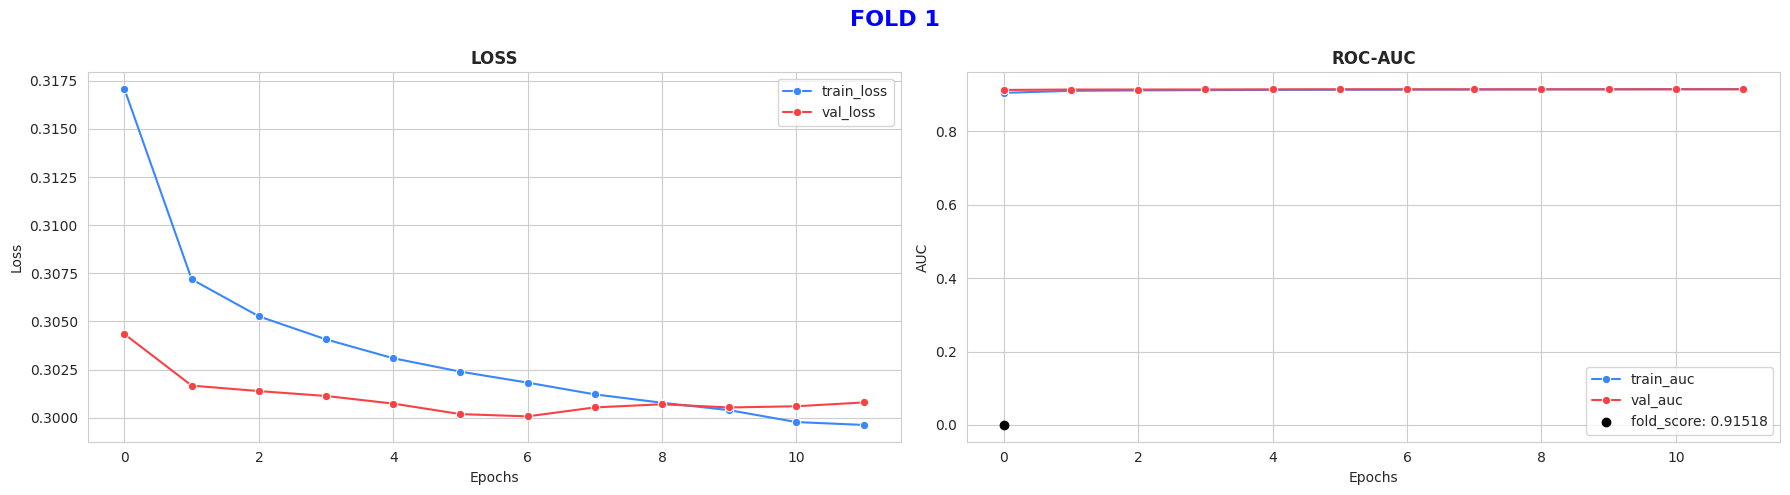

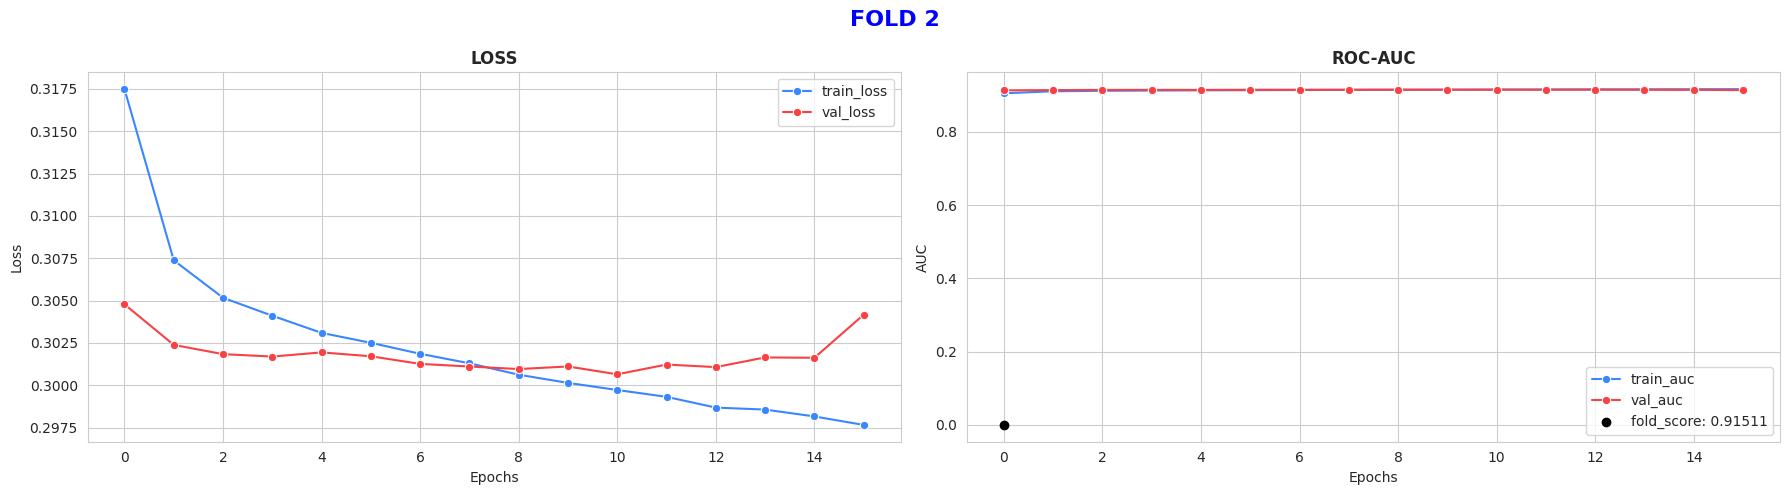

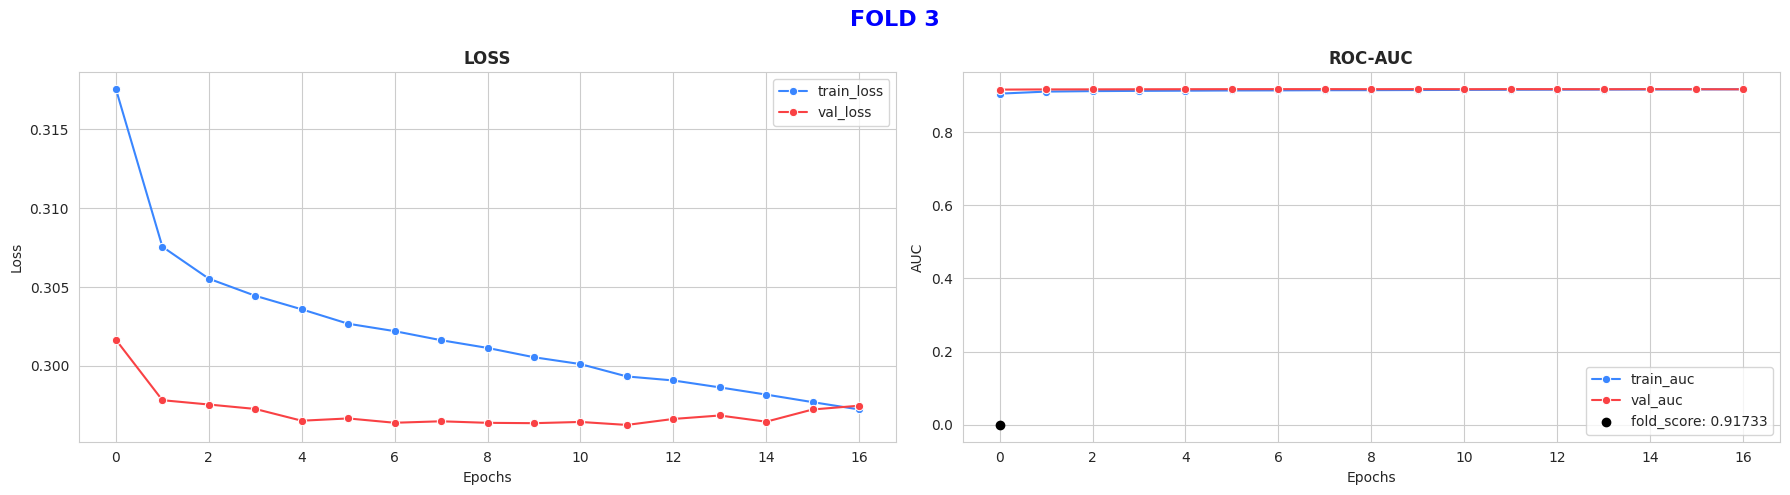

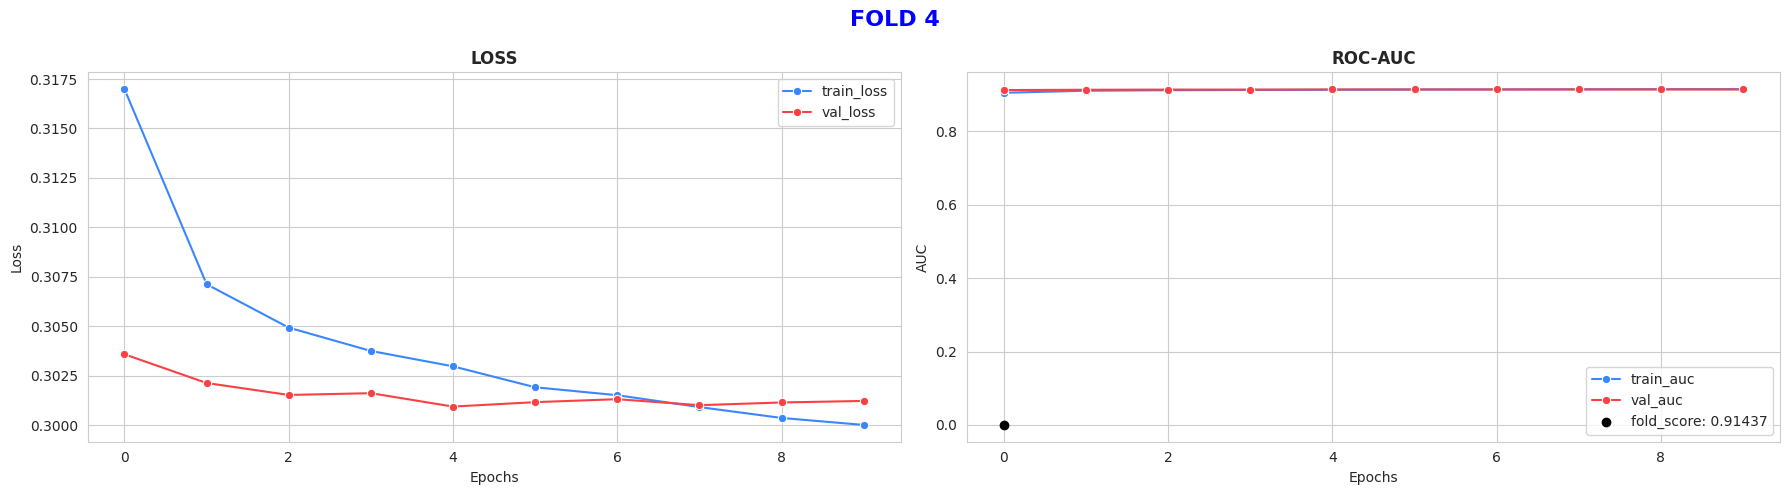

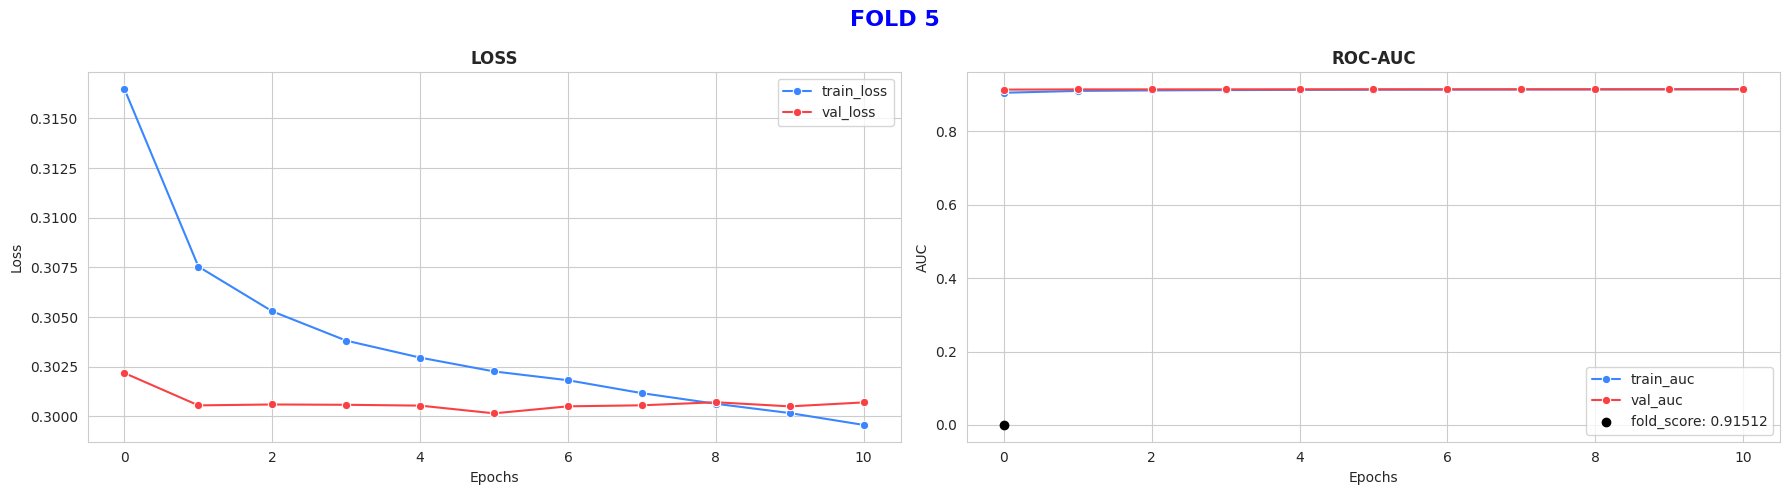

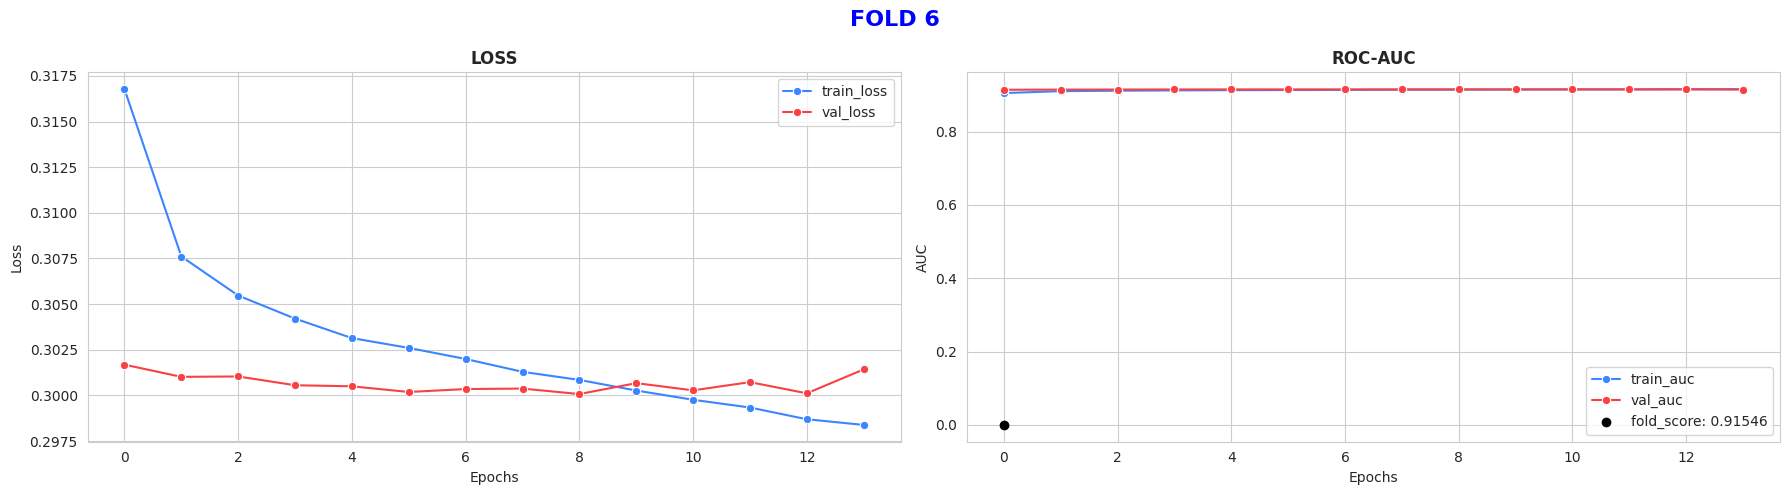

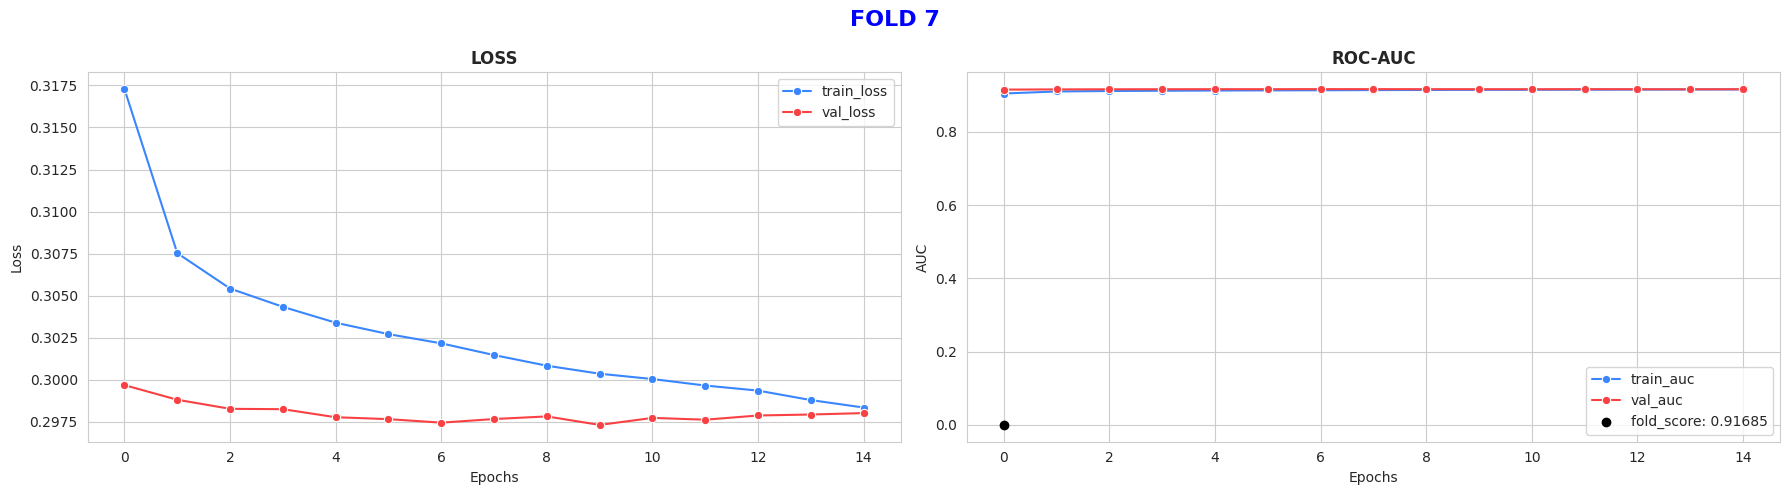

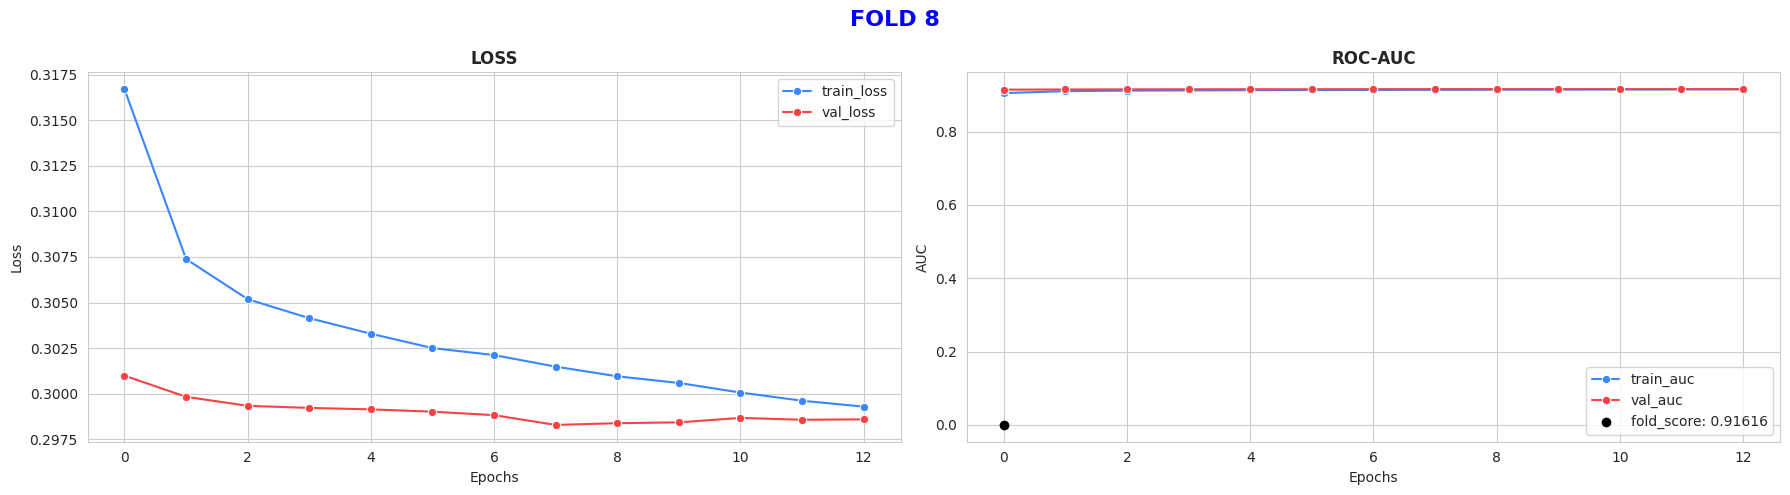

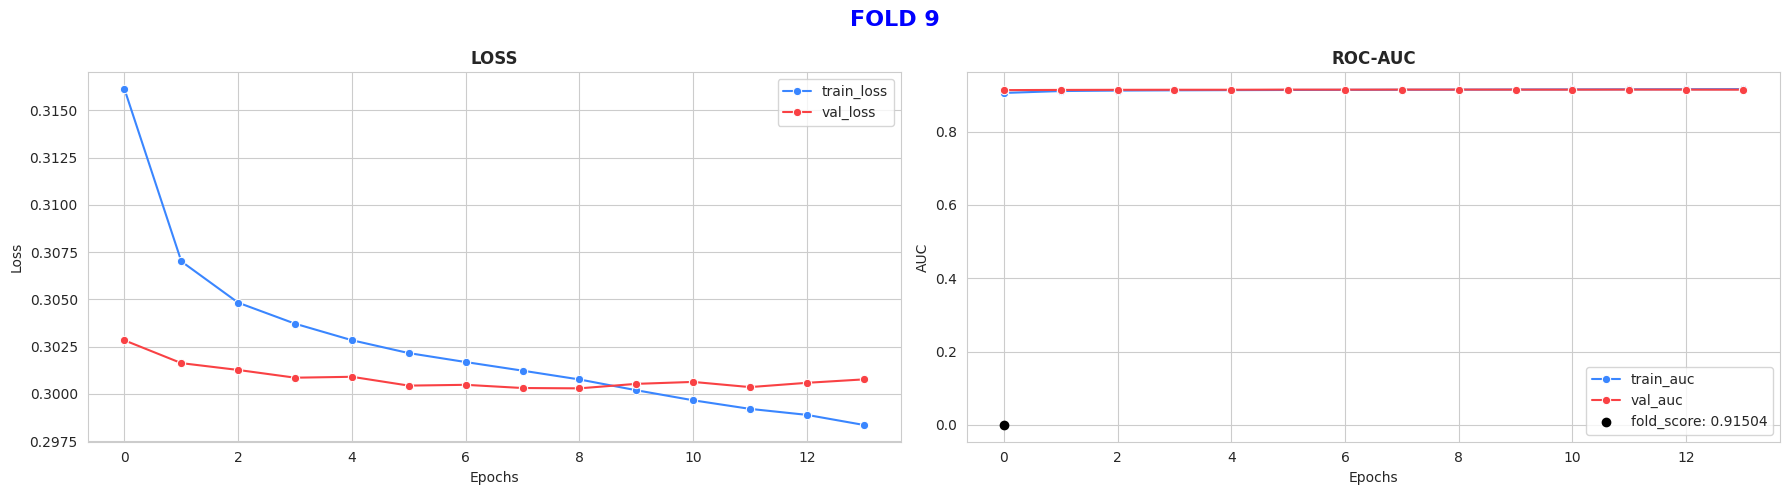

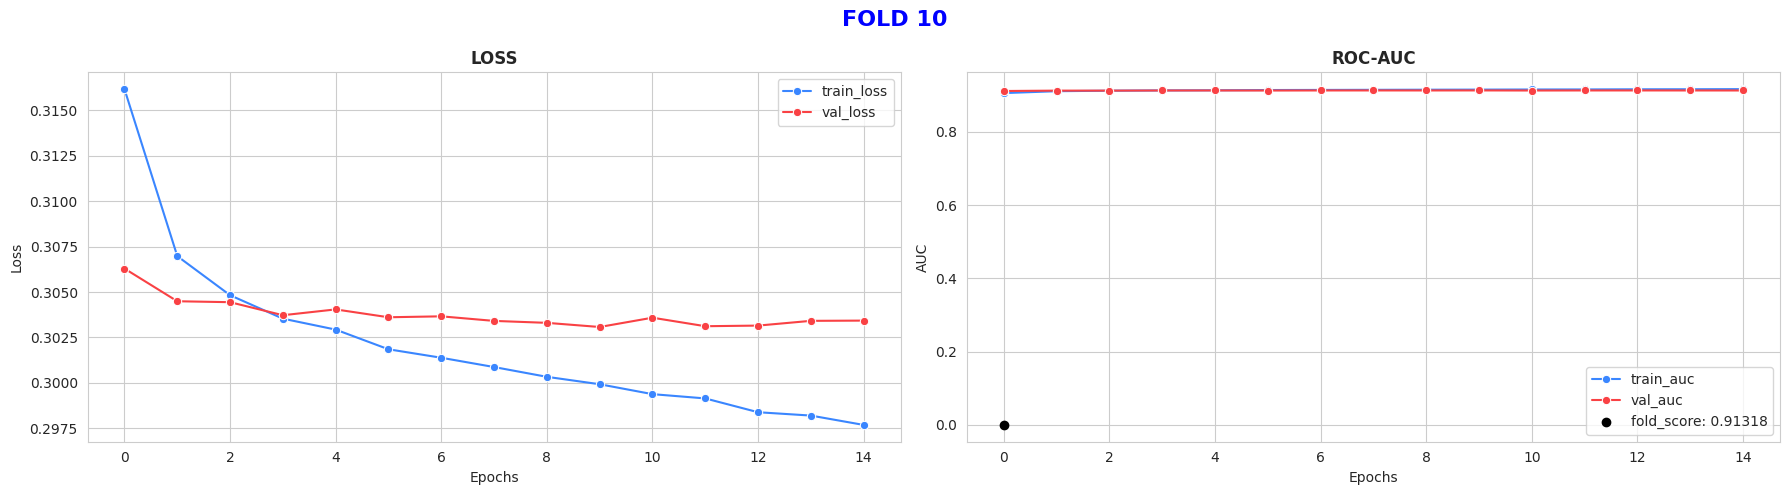

In [39]:
## -- PLOTTING RESULTS --
histories = result['history']

for i, data in tqdm(enumerate(histories), total=len(histories)):
    loss_results = pd.DataFrame({'train_loss': data['loss'], 'val_loss': data['val_loss']})
    auc_results = pd.DataFrame({'train_auc': data['auc'], 'val_auc': data['val_auc']})
    plt.figure(figsize=(18, 5))
    marker = 'o'

    ## -- PLOT LOSS --
    plt.subplot(121)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
    plt.title('LOSS', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    ## -- PLOT AUC --
    plt.subplot(122)
    sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
    sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
    plt.title('ROC-AUC', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')

    stat_ = f"fold_score: {result['fold_score'][i]:.5f}"
    plt.scatter(x=0, y=0, label=stat_, color='k')

    plt.suptitle(f"FOLD {i+1}", fontsize=16, fontweight='semibold', color='b')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    print()

In [40]:
n = version_name + str(np.round(np.mean(result['final_score']), 5)).split('.')[1]

np.save(f'oof_{n}.npy', result['oof_preds'])
np.save(f'test_{n}.npy', result['test_preds'])

submit[TARGET] = result['test_preds'].ravel()
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"Submission file exported as: 'submit_{n}.csv'")
submit.head()

Submission file exported as: 'submit_kerasV0_768_91532.csv'


,id,Churn
0,594194,0.077937
1,594195,0.001839
2,594196,0.081012
3,594197,0.003701
4,594198,0.513882
